## Lab 2: Differential Diagnosis and Conditional Expectation

### Fiona St.Clair

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
import graphviz

# Load data
df = pd.read_csv('./data/ed_visits_probability_lab_train.csv')
test = pd.read_csv('./data/ed_visits_probability_lab_test.csv')


A differential diagnosis is when a health care provider uses the availability of information about different symptoms to try to narrow down the set of possible health problems a patient might be experiencing, before recommending further testing or treatment.

We are not doctors, but we do have the National Hospital Ambulatory Medical Care Survey. The version we will use is **heavily** cleaned and simplified for our lab, please do not use it for research or any other purposes.

Here are the key pieces, in `./data/ed_visits_probability_lab_train.csv` and `./data/ed_visits_probability_lab_test.csv` files both contain:
- The patient's International Classification of Diseases (ICD) code has been simplified in the `disease_group` variable, with 18 categories like `cardiovascular` or `neurological`.
- There are binary symptoms: 'abdominal_pain', 'cough',
       'vomiting', 'fever', 'nausea', 'chest_pain', 'shortness_of_breath',
       'headache', 'accident', 'dizziness', 'back_pain', 'anxiety',
       'skin_rash'
- There are some other variables that likely have predictive value: `sex`, `arrival_by_ambulance`, and age group bins for under 20, 20-40, 40-60, 60-70, and over 70.

Note that you might have a skin rash because you have seborrheic dermatitis, and the underlying condition is actually Parkinson's Disease, which is neurological in nature. Likewise, a person who arrives in an ambulance with chest pain might be having a heart attack, but a walk-in with slight pain might be having an aortic dissection. Just because you have one kind of symptom that is representative of one class of diseases doesn't rule out complex or unexpected causes.

We are going to use the Decision Tree Classifier to learn more about conditional expectation. **This is not a lab about machine learning.** The decision tree classifier splits the sample according to questions about symptoms as it moves through the tree, and computes a probability mass function at each step that represents the proportions of the remaining part of the population with each of the disease codes.

## Step 1:

Run the code below, installing `scikit-learn` and `graphviz` as necessary.

In [2]:
# Symptom variables
symptoms = [
    'abdominal_pain', 'cough', 'vomiting', 'fever', 'nausea',
    'chest_pain', 'shortness_of_breath', 'headache', 'accident',
    'dizziness', 'back_pain', 'anxiety', 'skin_rash',
]

# Patient-context variables
patient_vars = [
    'arrival_by_ambulance', 'sex',
    'age_u20', 'age_20_40', 'age_40_60', 'age_60_70', 'age_o70',
]

x_vars = symptoms + patient_vars

# Explanatory-variable matrices
X = df[x_vars].to_numpy()
X_test = test[x_vars].to_numpy()

print('Disease groups:')
print(df['disease_group'].value_counts())


Disease groups:
disease_group
injury_trauma               17711
general_constitutional       8048
other                        5924
ear_nose_throat_eye          4800
gastrointestinal             3911
genitourinary_renal          3796
respiratory                  3688
psychiatric_behavioral       3637
musculoskeletal              3430
infectious_disease           2988
cardiovascular               2320
endocrine_metabolic          2012
dermatologic                 1811
injury_adverse_care          1511
neurological                 1270
pregnancy_related            1237
injury_poisoning              779
hepatobiliary_pancreatic      618
Name: count, dtype: int64


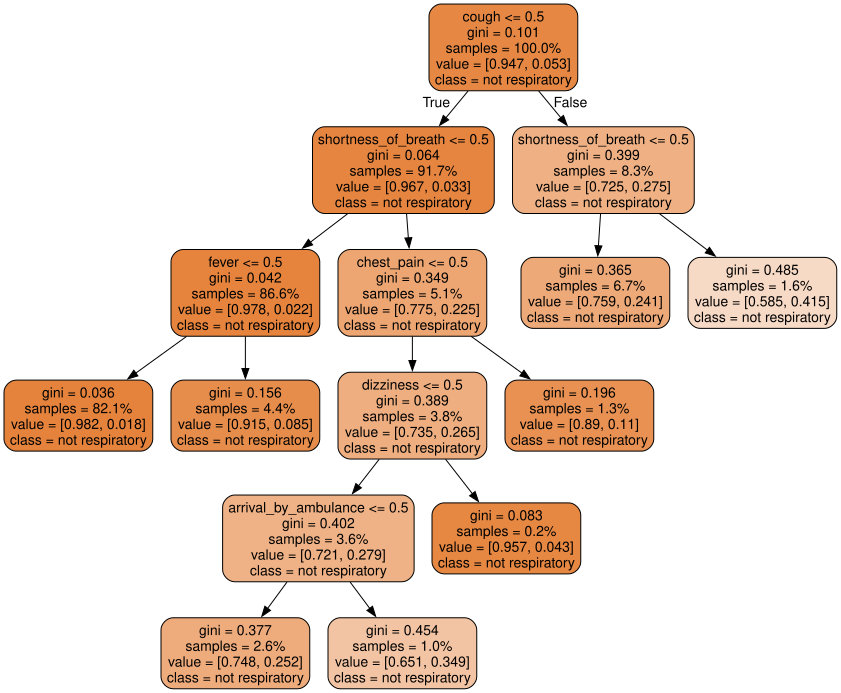

In [3]:
# Set outcome variable:
disease = 'respiratory'

## Construct outcome labels
y = (df['disease_group'] == disease).astype(int)
y_test = (test['disease_group'] == disease ).astype(int)
outcome = ['not ' + disease, disease]

## Set up tree classifier:
model = DecisionTreeClassifier(max_depth = 10, # Maximum tree depth
                              min_samples_leaf = 35, # Mininum cases per leaf
                              min_impurity_decrease = 1e-4, # Minimum impurity decrease to split a node
                              random_state = 100) # Random state for reproducibility

## Fit model to training data:
model.fit(X, y)

# Export the tree to Graphviz DOT format
from sklearn.tree import export_graphviz
dot_data = export_graphviz(
    model, 
    out_file=None, 
    feature_names=x_vars,
    class_names=outcome,
    filled=True, 
    proportion=True,
    rounded=True,
)

graph = graphviz.Source(dot_data)
graph

In [4]:
# re-written chart to break everything down easily (for my own sanity)

#                                                  COUGH?
#                                              (100%, 5.3% resp)
#                    ┌───────────────────────────────┴──────────────────┐
#                   NO                                                 YES
#              (91.7%, 3.3%)                                       (8.3%, 27.5%)
#                    │                                                  │
#        ┌───────────┴───────────┐                        ┌─────────────┴───────────┐
#   SOB: NO                  SOB: YES                   SOB: NO                  SOB: YES
# (86.6%, 2.2%)             (5.1%, 22.5%)              (6.7%, 24.1%)           (1.6%, 41.5%)
#     │                             │                    [END]                     [END]
# ┌───┴─────────┐           ┌───────┴───────┐
# FEVER:NO   FEVER:YES    CHEST:NO      CHEST:YES
# (82.1%,    (4.4%,       (3.8%,      (1.3%, 11.0%)
#  1.8%)      8.5%)       26.5%)          [END]
#  [END]      [END]          │
#                     ┌──────┴──────────┐
#                   DIZZY: NO       DIZZY: YES
#                 (3.6%, 27.9%)    (0.2%, 4.3%)
#                     │               [END]
#             ┌───────┴───────┐
#         AMBUL: NO        AMBUL: YES
#       (2.6%, 25.2%)     (1.0%, 34.9%)
#           [END]            [END]

# first % = % of all patients who fit into that one leaf
# second % = % of that specific leaf who actually have respiratory disease

The above object is a **decision tree classifier**: It predicts class labels on the basis of covariates. At each **node** in the graph, there is a condition, like `cough<=.5`. Depending on how the case evaluates, we move left (`True`) or right (`False`) down the tree along the **edges**. At each node, we also see the probability mass function, conditional on the current information set. At the bottom of the tree are **terminal leaves** with hard classification predictions and the final proportions.

The tree classifier pictured in the previous code chunk provides the probability mass function over the labels "not respiratory" and "respiratory". It starts as 95% of patients not having a respiratory problem, and 5% having a respiratory problem. The first differential diagnosis question is, "Does the patient have a cough?" If they do have a cough, we update our estimate to .73/.27, and if not, we update to .97/.03. If you have a cough, shortness of breath, you reach the highest estimate, .59/.41.

This is exactly what conditional probability and conditional expectation are: We update our beliefs based on evidence, and that reshapes our posterior estimates of the probabilities of different outcomes.

The probabilities displayed by the tree are fitted conditional estimates: they are the training-data class proportions among patients reaching each node. They are useful for this lab, but they are not calibrated clinical risk estimates.

<div class="alert alert-block alert-warning">

Which combinations of symptoms make a respiratory disease the most likely explanation? The least likely?

- The highest combination of symptoms to make respiratory disease the most likely explanation is 1) cough + shortness of breath with 41.5%, 2) no cough + shortness of breath + no chest pain + no dizziness + arrival by ambulance with 34.9%, and 3) no cough + shortness of breath + no chest pain + no dizziness + did not arrive by ambulance with 25.2%. 
- The lowest combination of symptoms to make respiratory disease the most likely explanation is no cough + no shortness of breath + no fever with 1.8%.

Which variables does the tree exploit? 

- The tree uses six variables, each appearing as a split somewhere in the tree: cough, shortness of breath, fever, chest pain, dizziness, and arrival by ambulance. The position of the variable on the tree tells us which are considered the most important with the higher variables being most important to predict respiratory disease (cough), and they become less significant as it flows done (such as dizziness or arrival by ambulance).

Clearly explain how the tree is a representation of conditional updating, where we condition on reported symptoms to provide new probability estimates based on new information.

- The tree starts at the base rate of respiratory disease (5.3%) before any symptoms are known. Each split on the reported symptom narrows the population to patients who share that answer and recalculates the probability within that smaller group. Moving down a branch means stacking conditions on top of each other, so each leaf represents the probability of respiratory disease conditioned on a combination of symptoms.

Run the code again, but try values of 1e-3=0.001, 1e-5=0.00001 and 1e-7=0.0000001 for `min_impurity_decrease` to allow it to explore more complex explanations of the data. For each value of the `min_impurity_decrease` hyperparameter, find the terminal leaves with the lowest and highest probabilities of respiratory disease. How do these values vary with the complexity of the tree?

- `min_impurity_decrease` = 1e-3=0.001
    - lowest: no cough + no SOB @ 0.022
    - highest: yes cough @ 0.275
- `min_impurity_decrease` = 1e-5=0.00001
    - lowest: no cough + no SOB + no fever + no chest pain + yes accident @ 0.0
    - highest: yes cough + yes SOB + yes chest pain + no headache + yes age over 70 + specific sex (nned to investigate how they classified this) @ 0.555
- `min_impurity_decrease` = 1e-7=0.0000001
    - lowest: multiple 0.00 probabilities present
    - highest: yes cough + yes SOB + no chest pain + no headache + yes age over 70 + sex = something (m/f) + no ambulance @ 0.577

- Lowering `min_impurity_decrease`makes the tree split into many more branches and creates smaller leaves of patients, which is why the spread between highest and lowest grows as the threshold decreases. This creates overfitting and less usable results, even though on paper, you would think it would be better.

</div>

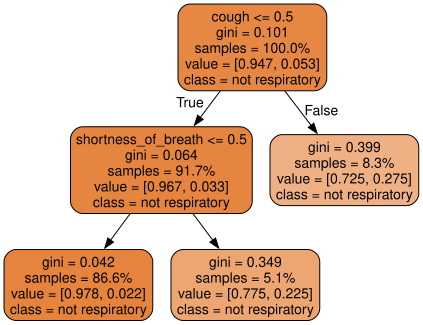

In [8]:
# Set outcome variable:
disease = 'respiratory'

## Construct outcome labels
y = (df['disease_group'] == disease).astype(int)
y_test = (test['disease_group'] == disease ).astype(int)
outcome = ['not ' + disease, disease]

## Set up tree classifier:
model = DecisionTreeClassifier(max_depth = 10, # Maximum tree depth
                              min_samples_leaf = 35, # Mininum cases per leaf
                              min_impurity_decrease = 1e-3, # Minimum impurity decrease to split a node
                              random_state = 100) # Random state for reproducibility

## Fit model to training data:
model.fit(X, y)

# Export the tree to Graphviz DOT format
from sklearn.tree import export_graphviz
dot_data = export_graphviz(
    model, 
    out_file=None, 
    feature_names=x_vars,
    class_names=outcome,
    filled=True, 
    proportion=True,
    rounded=True,
)

graph = graphviz.Source(dot_data)
graph

<div class="alert alert-block alert-warning">

Repeat the previous step with `disease = 'neurological'` and `min_impurity_decrease = 1e-3`. What variables are used in the tree? Which variables raise or lower the predicted probability of a neurological diagnosis?

- This tree is just one node with the base rate, so its not actually doing any conditioning with other symptoms. It tells us that 98.2% of patients in the data are not experiencing 'neurological' and 1.8% of the node (or in this case, the entire dataset) are 'neurological'. 

</div>

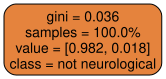

In [6]:
# Set outcome variable:
disease = 'neurological'

## Construct outcome labels
y = (df['disease_group'] == disease).astype(int)
y_test = (test['disease_group'] == disease ).astype(int)
outcome = ['not ' + disease, disease]

## Set up tree classifier:
model = DecisionTreeClassifier(max_depth = 10, # Maximum tree depth
                              min_samples_leaf = 35, # Mininum cases per leaf
                              min_impurity_decrease = 1e-3, # Minimum impurity decrease to split a node
                              random_state = 100) # Random state for reproducibility

## Fit model to training data:
model.fit(X, y)

# Export the tree to Graphviz DOT format
from sklearn.tree import export_graphviz
dot_data = export_graphviz(
    model, 
    out_file=None, 
    feature_names=x_vars,
    class_names=outcome,
    filled=True, 
    proportion=True,
    rounded=True,
)

graph = graphviz.Source(dot_data)
graph

## Step 2:

In step 1, we tried to predict whether a patient has a single condition or not. Now, we want to predict the entire probability mass function.

The code block sets `y = df['disease_group']` and `outcome = df['disease_group'].unique()`, and runs a similar analysis. The result is now a fitted differential diagnosis: an estimated probability mass function over the labels and a hard classification label. For readability, we set `max_depth = 3`.

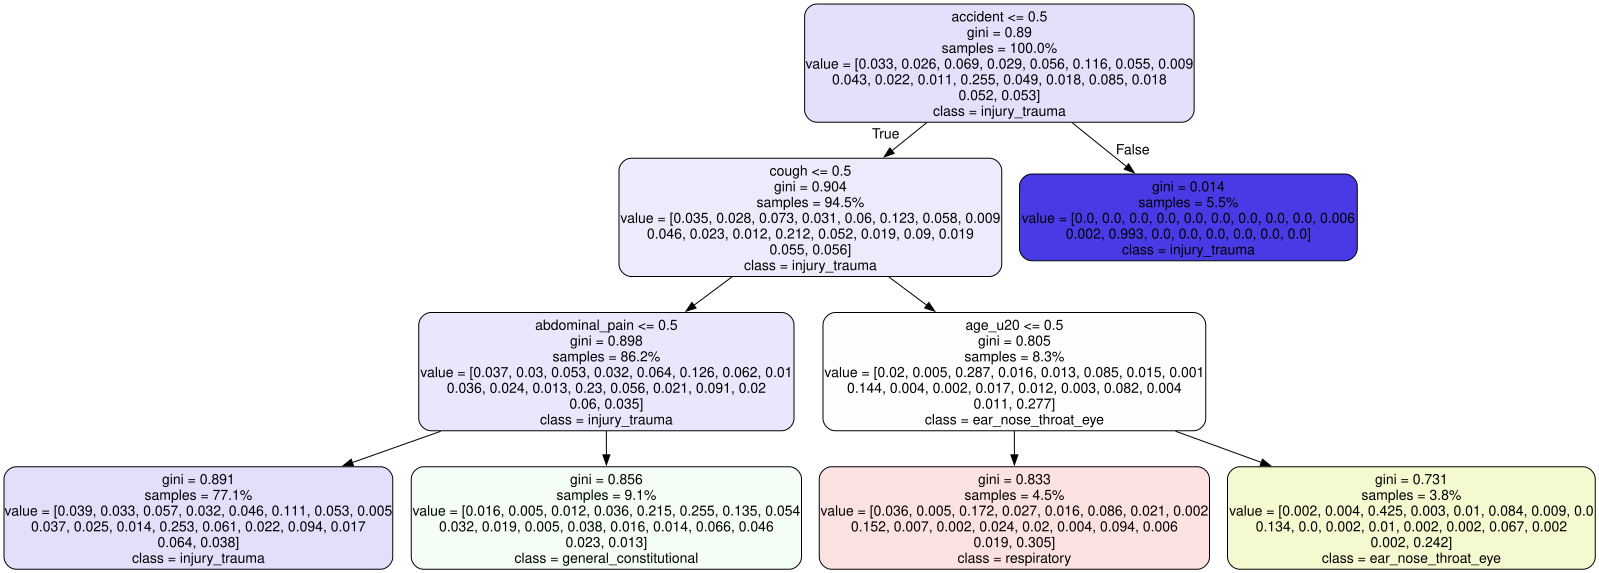

In [7]:
# Set outcome variable:
y = df['disease_group']
## Set up tree classifier:
model = DecisionTreeClassifier(max_depth = 3, # Maximum tree depth
                              min_samples_leaf = 35, # Mininum cases per leaf
                              min_impurity_decrease = 1e-4, # Minimum impurity decrease to split a node
                              random_state = 100) # Random state for reproducibility

## Fit model to training data:
model.fit(X, y)


# Export the tree to Graphviz DOT format
from sklearn.tree import export_graphviz
dot_data = export_graphviz(
    model, 
    out_file=None, 
    feature_names=x_vars,
    class_names=model.classes_,
    filled=True, 
    proportion=True,
    rounded=True,
)

graph = graphviz.Source(dot_data)
graph

<div class="alert alert-block alert-warning">

Which diseases are predicted as hard classifications in the tree? For those labels, does the probability of that disease exceed even a moderate value like .3 or .5, or not? Why might this be a concern?

- Hard classifications are the end nodes, so trauma injury, general constitutional, respiratory, ear/nose/throat/eye. Apart from the one high confidence blue injury_trauma leaf, none of these diseases come close to a probability of 0.5, and most don't clear 0.3. It's concerning that one node has such a high probability all by itself, and the only other options are super low. It suggests that we need to restructure this tree/our classifications to make it more spread out. 

Which labels have the highest or lowest probabilities for the predicted disease class labels? 

- highest: yes accident (predicted injury trauma) @ .993
- lowest: no accident + no cough + no abdominal pain (predicted general constitutional) @ .253 

Which conditions and values are used in the tree?

- The four conditions are accident ≤ 0.5 (at the root), cough ≤ 0.5, abdominal pain ≤ 0.5, and age under 20 ≤ 0.5.

Even if the probabilities for each terminal leaf remain fairly small in absolute terms, why can a differential diagnosis tool like this still be useful for doctors?

- Even though it's not near certainty, the tool could still be useful because it's still a boost above the baseline and helps narrow down which diagnosises would be best to investigate. So it's less of a diagnostic tool at this stage, but it can help steer them in the right direction and help doctors prioritize. 

</div>